Wizualizacje metryk równania Poissona, które jest strukturalnie podobne do naszego równania, ale należało dodać nieliniowy współczynnik, użyć Newton Solver, zdefiniować funkcje źródła, przerobić na równanie niestacjonarne, czyli zastosować dyskretyzacje np. metodą eulera, w tym przypadku Euler w tył.

In [1]:
import meshio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("results/metrics/metrics_stability.csv")

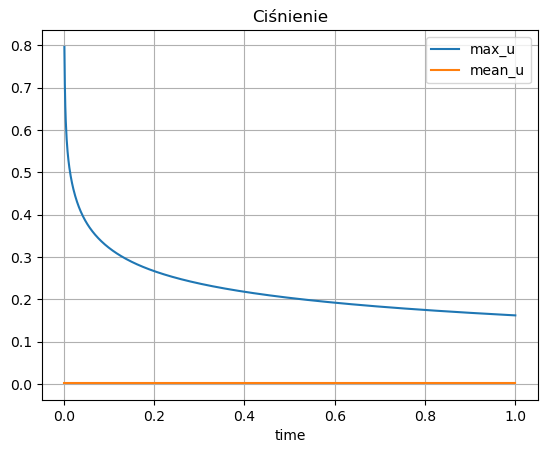

In [2]:
df.plot(x='time', y=['max_u', 'mean_u'], title='Ciśnienie')
plt.grid(True)
plt.show()

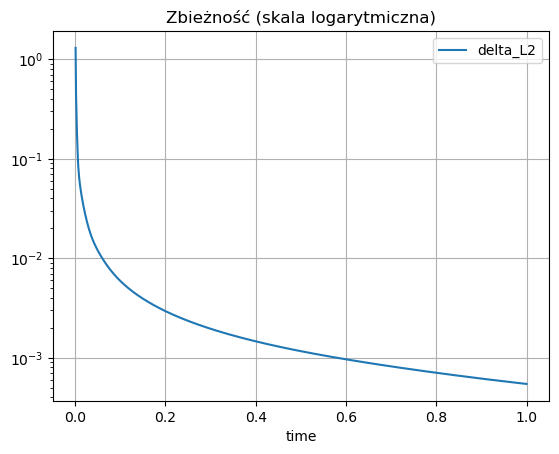

In [3]:
df.plot(x='time', y='delta_L2', logy=True, title='Zbieżność (skala logarytmiczna)')
plt.grid(True)
plt.show()

In [4]:
print(df[['max_u', 'delta_L2']].describe())

             max_u     delta_L2
count  1000.000000  1000.000000
mean      0.228464     0.005397
std       0.075866     0.045170
min       0.161992     0.000546
25%       0.178523     0.000760
50%       0.203232     0.001164
75%       0.249883     0.002345
max       0.795975     1.299368


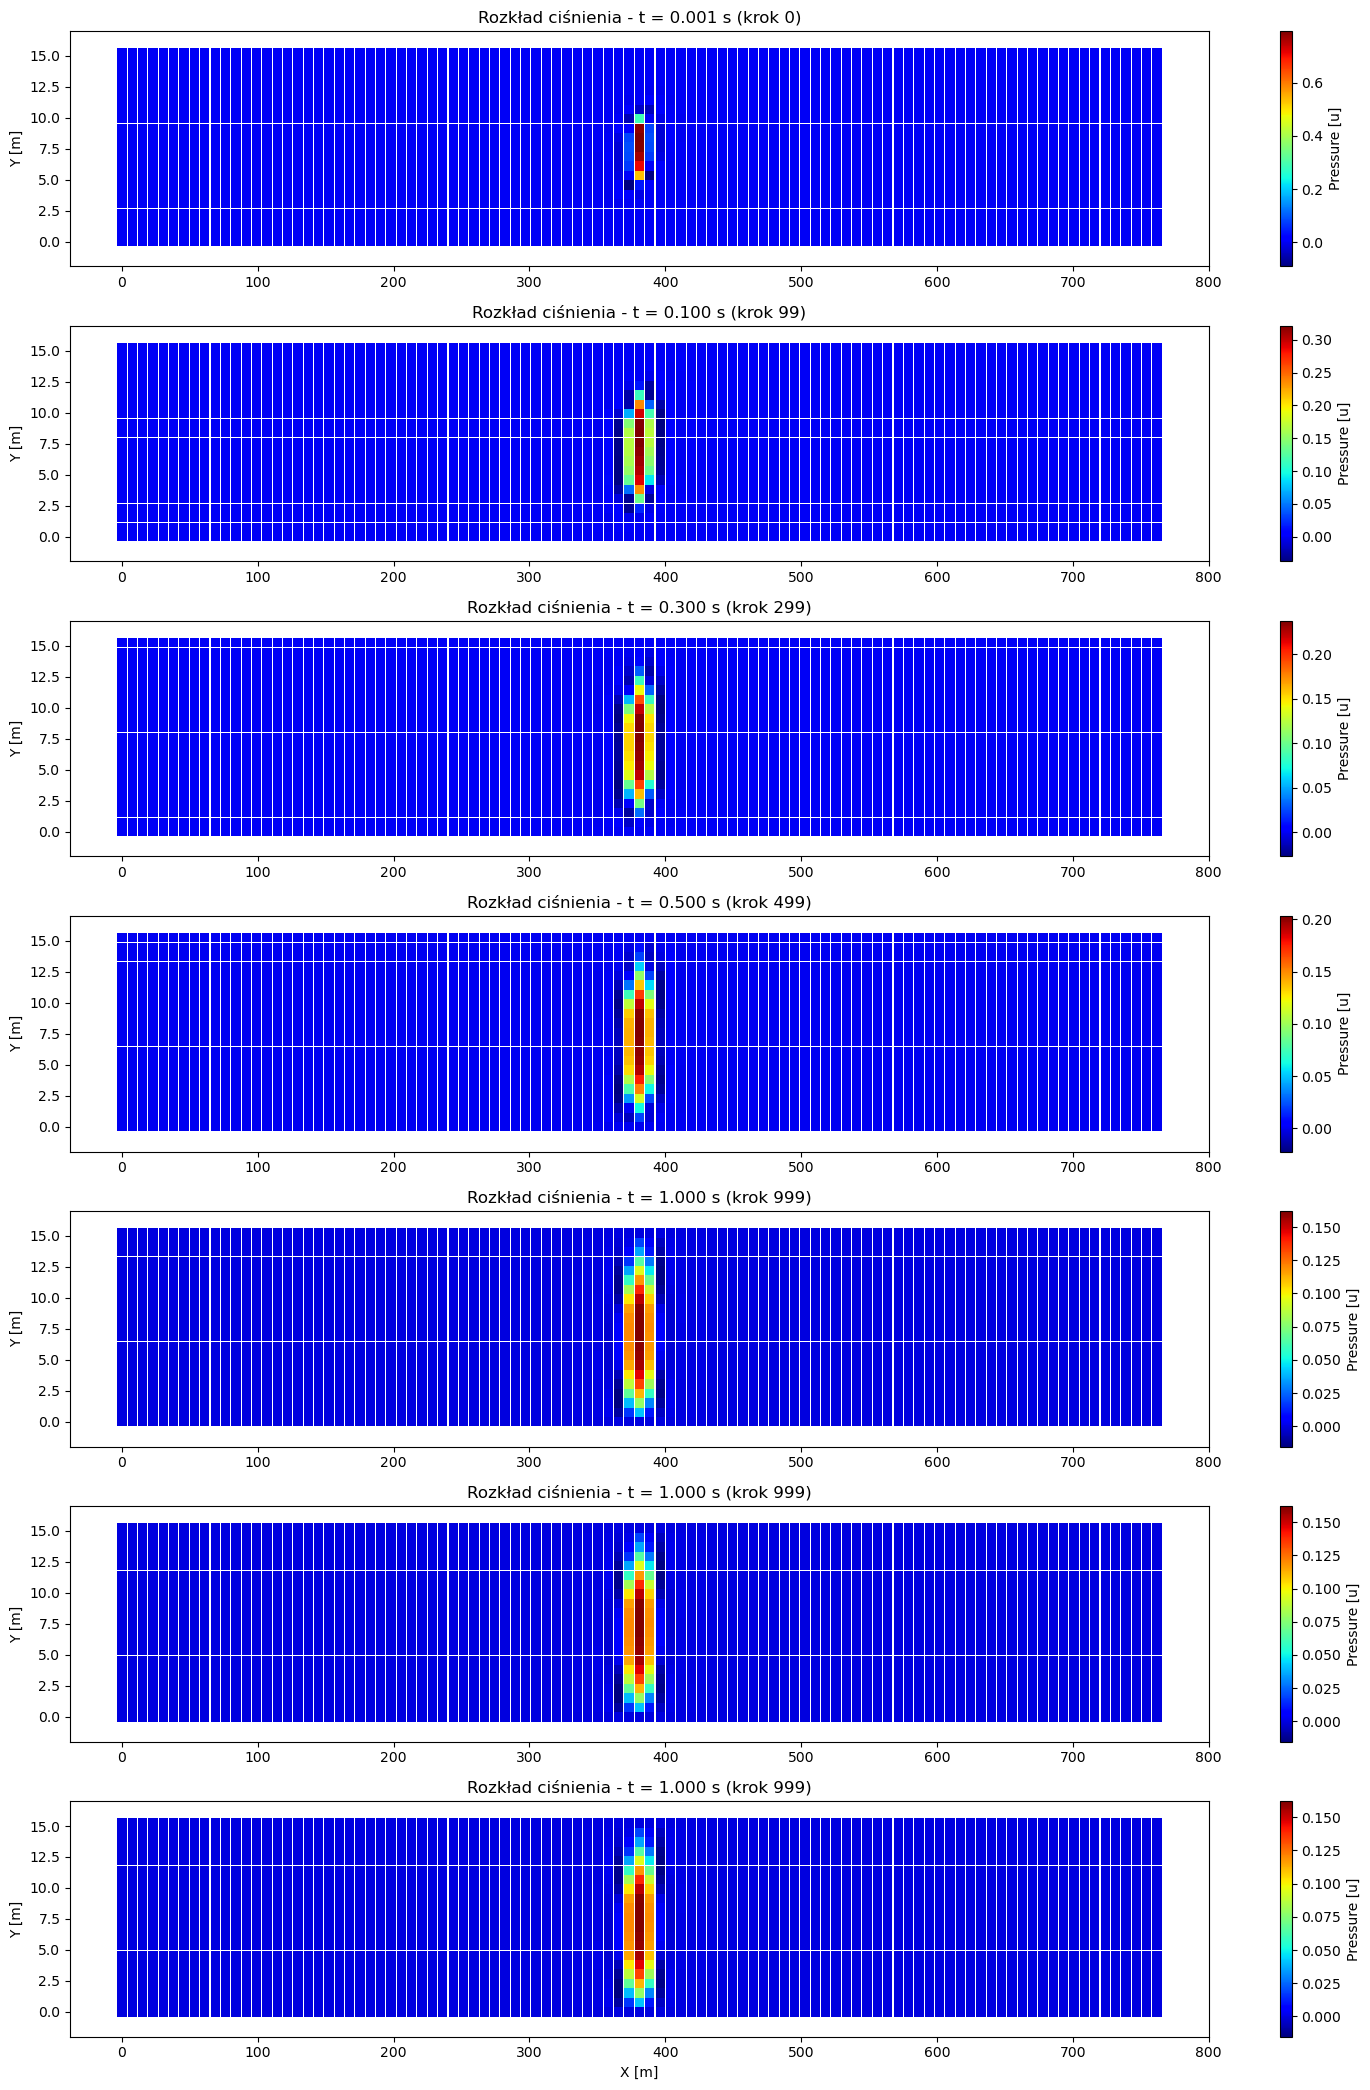

In [5]:
file_path = "/mnt/c/PINN_mgr/FEniCS/eq_newton_spe/results/fields/solution_stability.xdmf"
target_times = [0.0, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0] 

with meshio.xdmf.TimeSeriesReader(file_path) as reader:
    points, _ = reader.read_points_cells()
    
    available_times = []
    for i in range(reader.num_steps):
        t, _, _ = reader.read_data(i)
        available_times.append(t)
    available_times = np.array(available_times)

    fig, axes = plt.subplots(len(target_times), 1, figsize=(15, 3 * len(target_times)))
    if len(target_times) == 1: axes = [axes] 

    for ax, t_target in zip(axes, target_times):
        idx = (np.abs(available_times - t_target)).argmin()
        t_actual, point_data, _ = reader.read_data(idx)
        u_values = point_data["Pressure"]

        sc = ax.scatter(points[:, 0], points[:, 1], c=u_values, 
                        cmap='jet', s=45, marker='s', edgecolors='none')
        
        ax.set_title(f"Rozkład ciśnienia - t = {t_actual:.3f} s (krok {idx})")
        ax.set_ylabel("Y [m]")
        ax.set_ylim(-2, 17) 
        plt.colorbar(sc, ax=ax, label='Pressure [u]')

    axes[-1].set_xlabel("X [m]")
    plt.tight_layout()
    plt.show()

In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [7]:
reader = meshio.xdmf.TimeSeriesReader(file_path)
points, _ = reader.read_points_cells()
num_steps = reader.num_steps

fig, ax = plt.subplots(figsize=(15, 3))
sc = ax.scatter(points[:, 0], points[:, 1], c=np.zeros(len(points)), 
                cmap='jet', s=45, marker='s', edgecolors='none', vmin=0, vmax=0.6)

plt.colorbar(sc, label='Pressure [u]')
ax.set_ylim(-5, 20)
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
title = ax.set_title("Rozkład ciśnienia - t = 0.000")

def update(frame):
    t, point_data, _ = reader.read_data(frame)
    u_values = point_data["Pressure"].flatten() 
    sc.set_array(u_values)
    title.set_text(f"Rozkład ciśnienia - t = {t:.3f}")
    return sc, title

ani = FuncAnimation(fig, update, frames=range(0, num_steps, 10), interval=100, blit=True)

plt.close() 
HTML(ani.to_jshtml())

Punkty do porównywania z PINN

In [8]:
import numpy as np
import matplotlib.pyplot as plt

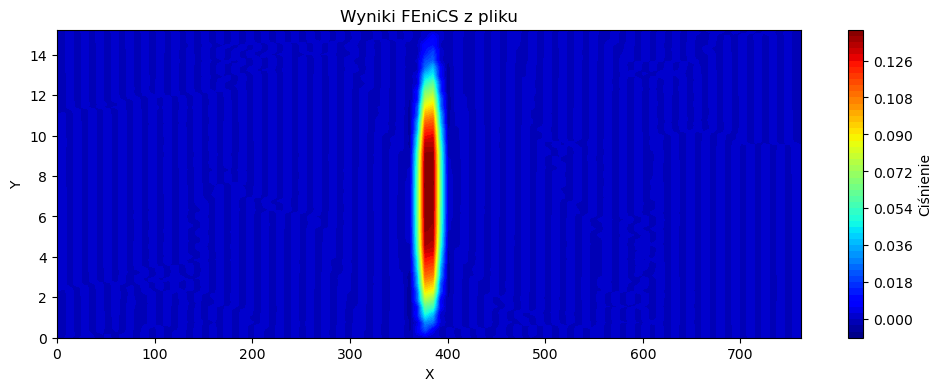

Kształt macierzy u: (100, 100)
Max val u: 0.14090293867246634


In [9]:
data = np.load("results/metrics/fenics_for_pinn_comparison_stability.npy", allow_pickle=True).item()
x = data['x']
y = data['y']
u = data['u_fenics']

plt.figure(figsize=(12, 4))
contour = plt.contourf(x, y, u, levels=50, cmap='jet')
plt.colorbar(contour, label='Ciśnienie')
plt.title("Wyniki FEniCS z pliku")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

print(f"Kształt macierzy u: {u.shape}")
print(f"Max val u: {np.nanmax(u)}")

In [10]:
row, col = 99, 99

print(f"Indeksy: [{row}, {col}]")
print(f"Współrzędne: x = {x[row, col]:.2f}, y = {y[row, col]:.2f}")
print(f"Wartość ciśnienia (u): {u[row, col]:.6f}")

Indeksy: [99, 99]
Współrzędne: x = 762.00, y = 15.24
Wartość ciśnienia (u): -0.000000


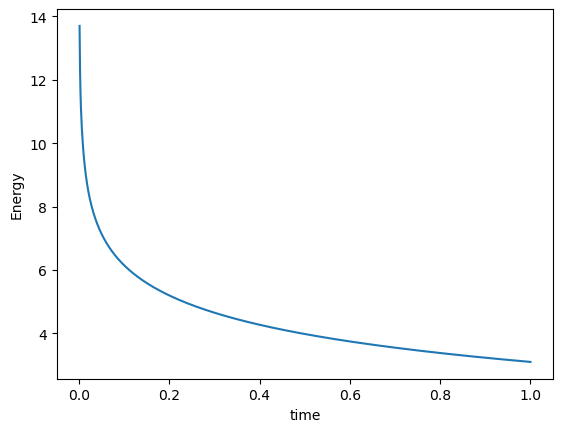

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

data = df

plt.plot(data["time"], data["energy"])
plt.xlabel("time")
plt.ylabel("Energy")
plt.show()